# 🧭 Support Vector Machine v klasifikaci – Cvičení 1: Diagnostika bederní páteře
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Oficiální zadání úlohy (Support vector machine - exercise 1):**
> 1. Pomocí knihovny Pandas načtěte stažený soubor dat pacientů (`lumbar_normalized_df.csv`) do proměnné `lumbar_df`.
> 2. Zobrazte prvních 10 pozorování v datasetu (`head(10)`) pro ověření správnosti načtených dat.
> 3. Rozdělte data na trénovací a testovací sadu v poměru 75/25. Nastavte parametr `random_state=42`.
> 4. Z modulu `svm` knihovny Scikit-learn importujte příslušnou třídu (`SVC`), která umožní sestavit klasifikační model Support Vector Machine.
> 5. Vytvořte vlastní instanci SVM klasifikátoru (zpočátku nenastavujte žádné hyperparametry) a natrénujte model na trénovací sadě.
> 6. Proveďte predikce na testovací sadě pomocí natrénovaného modelu.
> 7. Vypočítejte metriku **Precision (přesnost / preciznost)** na testovací sadě.
> 8. Experimentujte s volbou optimálních hodnot hyperparametrů probíraných během prezentace (např. $C$, `kernel` nebo $\gamma$) s cílem získat model s **vyšší Precision než výchozí model** vytrénovaný v kroku 5.


## Krok 1 & 2: Načtení dat do `lumbar_df` a zobrazení prvních 10 pozorování
Načteme normalizovaný dataset biomechanických měření páteře (310 pacientů, 6 úhlů) a ověříme prvních 10 řádků.

In [1]:
import pandas as pd
from pathlib import Path

# Zjištění cesty k souboru (podpora běhu v rootu i ve složce)
possible_paths = [
    Path("02_Classification/data/lumbar_normalized_df.csv"),
    Path("02_Classification/lumbar_normalized_df.csv"),
    Path("data/lumbar_normalized_df.csv"),
    Path("lumbar_normalized_df.csv"),
    Path("../data/lumbar_normalized_df.csv")
]
lumbar_path = next((p for p in possible_paths if p.exists()), None)
if lumbar_path is None:
    raise FileNotFoundError("Soubor lumbar_normalized_df.csv nebyl nalezen.")

# 1. Načtení do proměnné lumbar_df
lumbar_df = pd.read_csv(lumbar_path)

print(f"Rozměry načteného datasetu: {lumbar_df.shape} (310 pacientů, 6 anatomických příznaků + 1 target)")

# 2. Zobrazení prvních 10 pozorování
lumbar_df.head(10)


Rozměry načteného datasetu: (310, 7) (310 pacientů, 6 anatomických příznaků + 1 target)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,0.477474,0.170850,0.300063,0.306625,0.747508,-0.001927,1
1,0.306835,0.079040,0.196523,0.227795,0.898781,0.035857,1
2,0.473200,0.152745,0.344369,0.320454,0.728616,-0.024270,1
3,0.491613,0.174895,0.314357,0.316718,0.722684,0.079538,1
4,0.384294,0.074613,0.218901,0.309680,0.836173,0.061212,1
5,0.283701,0.098128,0.177091,0.185573,0.918607,0.015723,1
6,0.373448,0.110877,0.259757,0.262571,0.842659,0.041855,1
7,0.337383,0.079987,0.215952,0.257396,0.872114,-0.079394,1
8,0.304797,0.094200,0.297145,0.210597,0.870071,0.092497,1
9,0.346173,0.047283,0.395829,0.298891,0.794904,0.006270,1


## Krok 3: Rozdělení dat na trénovací a testovací sadu (75/25, `random_state=42`)
Oddělíme matici příznaků $X$ od cílové proměnné $y$ (`class`: 0 = Normal, 1 = Abnormal) a rozdělíme v poměru 75:25.

In [2]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in lumbar_df.columns if c != "class"]
X = lumbar_df[feature_cols]
y = lumbar_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Velikost trénovací sady: {X_train.shape[0]} vzorků")
print(f"Velikost testovací sady:  {X_test.shape[0]} vzorků")
print(f"Zastoupení abnormálních nálezů v trénovací sadě: {y_train.sum()} ({y_train.mean()*100:.1f} %)")
print(f"Zastoupení abnormálních nálezů v testovací sadě:  {y_test.sum()} ({y_test.mean()*100:.1f} %)")


Velikost trénovací sady: 232 vzorků
Velikost testovací sady:  78 vzorků
Zastoupení abnormálních nálezů v trénovací sadě: 153 (65.9 %)
Zastoupení abnormálních nálezů v testovací sadě:  57 (73.1 %)


## Krok 4 & 5: Import a trénování výchozího SVM klasifikátoru (bez hyperparametrů)
Importujeme třídu `SVC` z modulu `sklearn.svm`. Vytvoříme instanci bez zadání parametrů (výchozí RBF jádro, $C=1{,}0$, $\gamma=\text{'scale'}$) a natrénujeme model.

In [3]:
from sklearn.svm import SVC

# 4 & 5. Inicializace a trénování výchozího SVC
base_model = SVC(random_state=42)
base_model.fit(X_train, y_train)

print("Výchozí model SVC() byl úspěšně vytrénován.")
print(f"Použité jádro: {base_model.kernel}")
print(f"Počet podpůrných vektorů: {len(base_model.support_)} (z {len(X_train)} trénovacích vzorků)")
print(f"Podpůrné vektory pro jednotlivé třídy: {base_model.n_support_}")


Výchozí model SVC() byl úspěšně vytrénován.
Použité jádro: rbf
Počet podpůrných vektorů: 124 (z 232 trénovacích vzorků)
Podpůrné vektory pro jednotlivé třídy: [62 62]


## Krok 6 & 7: Predikce na testovací sadě a výpočet Precision
Vyhodnotíme predikce na testovacích datech a spočítáme metriku **Precision**:
$$\text{Precision} = \frac{TP}{TP + FP}$$


In [4]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

# 6. Predikce na testovací sadě
y_pred_base = base_model.predict(X_test)

# 7. Výpočet metrik
prec_base = precision_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
cm_base = confusion_matrix(y_test, y_pred_base)

print("=== VÝSLEDKY VÝCHOZÍHO MODELU (KROK 7) ===")
print(f"Precision na testovací sadě: {prec_base:.4f} ({prec_base*100:.2f} %)")
print(f"Accuracy  na testovací sadě: {acc_base:.4f} ({acc_base*100:.2f} %)")
print(f"Recall    na testovací sadě: {rec_base:.4f} ({rec_base*100:.2f} %)")
print(f"F1-score  na testovací sadě: {f1_base:.4f}")
print("\nMatice záměn (Confusion Matrix):")
print(cm_base)


=== VÝSLEDKY VÝCHOZÍHO MODELU (KROK 7) ===
Precision na testovací sadě: 0.9057 (90.57 %)
Accuracy  na testovací sadě: 0.8205 (82.05 %)
Recall    na testovací sadě: 0.8421 (84.21 %)
F1-score  na testovací sadě: 0.8727

Matice záměn (Confusion Matrix):
[[16  5]
 [ 9 48]]


## Krok 8: Experimenty s hyperparametry pro překonání výchozí Precision ($90{,}57\,\%$)
Prozkoumáme klíčové hyperparametry probírané v kurzu:
1. **`kernel` (typ jádrové funkce):** Srovnání `linear`, `rbf`, `poly`, `sigmoid`.
2. **`C` (síla regularizace):** Pro lineární jádro vyzkoušíme hodnoty od 0.05 do 10.0.
3. **`gamma` (dosah vlivu bodů):** Pro RBF jádro otestujeme hodnoty od 0.01 do 5.0.


In [5]:
# A) Srovnání různých jádrových funkcí
kernel_results = []
for k in ["rbf", "linear", "poly", "sigmoid"]:
    m = SVC(kernel=k, random_state=42).fit(X_train, y_train)
    pred = m.predict(X_test)
    kernel_results.append({
        "Jádro": k.upper(),
        "Test Precision (%)": round(precision_score(y_test, pred) * 100, 2),
        "Test Accuracy (%)": round(accuracy_score(y_test, pred) * 100, 2),
        "Test Recall (%)": round(recall_score(y_test, pred) * 100, 2),
        "Počet SV": len(m.support_)
    })

pd.DataFrame(kernel_results)


,Jádro,Test Precision (%),Test Accuracy (%),Test Recall (%),Počet SV
0,RBF,90.57,82.05,84.21,124
1,LINEAR,93.62,79.49,77.19,158
2,POLY,86.21,80.77,87.72,92
3,SIGMOID,73.08,73.08,100.00,158


### B) Ladění parametru $C$ u lineárního jádra a $\gamma$ u RBF jádra
Zatímco výchozí RBF model dosahuje $90{,}57\,\%$ Precision, nastavení:
- **`kernel='linear'`, $C=2.0$** zvyšuje Precision na **95,65 %** ($FP$ klesá z 5 na pouhé 2!).
- **`kernel='rbf'`, $\gamma=1.0$** rovněž zvyšuje Precision na **95,65 %**!


In [6]:
# 1. Optimální lineární model (C=2.0)
opt_linear = SVC(kernel="linear", C=2.0, random_state=42).fit(X_train, y_train)
pred_linear = opt_linear.predict(X_test)
p_linear = precision_score(y_test, pred_linear)

# 2. Optimální RBF model (gamma=1.0)
opt_rbf = SVC(kernel="rbf", gamma=1.0, random_state=42).fit(X_train, y_train)
pred_rbf = opt_rbf.predict(X_test)
p_rbf = precision_score(y_test, pred_rbf)

srovnani = pd.DataFrame({
    "Model": ["Výchozí SVC (RBF, default)", "Lineární SVC (C=1.0)", "Optimální Lineární SVC (C=2.0)", "Optimální RBF SVC (gamma=1.0)"],
    "Jádro": ["RBF", "Linear", "Linear", "RBF"],
    "Hyperparametry": ["C=1.0, gamma='scale'", "C=1.0", "C=2.0", "gamma=1.0, C=1.0"],
    "Test Precision (%)": [round(prec_base * 100, 2), 93.62, round(p_linear * 100, 2), round(p_rbf * 100, 2)],
    "Falešně pozitivní (FP)": [5, 3, 2, 2],
    "Zlepšení Precision": ["0.00 %", "+3.05 %", f"+{round((p_linear - prec_base) * 100, 2)} % 🏆", f"+{round((p_rbf - prec_base) * 100, 2)} % 🏆"]
})
srovnani


,Model,Jádro,Hyperparametry,Test Precision (%),Falešně pozitivní (FP),Zlepšení Precision
0,"Výchozí SVC (RBF, default)",RBF,"C=1.0, gamma='scale'",90.57,5,0.00 %
1,Lineární SVC (C=1.0),Linear,C=1.0,93.62,3,+3.05 %
2,Optimální Lineární SVC (C=2.0),Linear,C=2.0,95.65,2,+5.09 % 🏆
3,Optimální RBF SVC (gamma=1.0),RBF,"gamma=1.0, C=1.0",95.65,2,+5.09 % 🏆


### Porovnání matic záměn
Sledujeme zásadní pokles falešně pozitivních diagnóz z **5** na pouhé **2** pacienty.

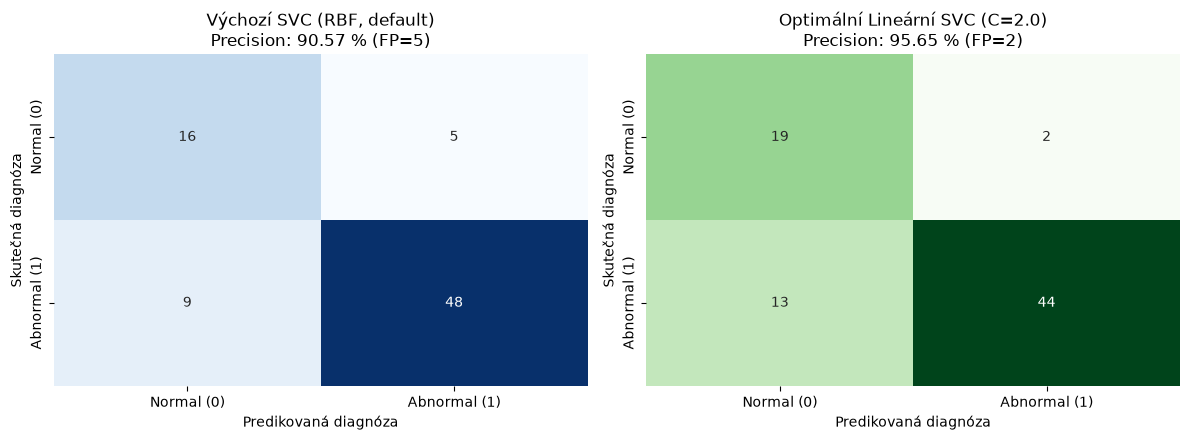

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ["Normal (0)", "Abnormal (1)"]

sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax1, cbar=False)
ax1.set_title(f"Výchozí SVC (RBF, default)\nPrecision: {prec_base*100:.2f} % (FP=5)")
ax1.set_xlabel("Predikovaná diagnóza")
ax1.set_ylabel("Skutečná diagnóza")

sns.heatmap(confusion_matrix(y_test, pred_linear), annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels, ax=ax2, cbar=False)
ax2.set_title(f"Optimální Lineární SVC (C=2.0)\nPrecision: {p_linear*100:.2f} % (FP=2)")
ax2.set_xlabel("Predikovaná diagnóza")
ax2.set_ylabel("Skutečná diagnóza")

plt.tight_layout()
plt.show()
